## Cardiovascular Disease Prediction

Objective:
- Exploratory Data Analysis. 
- Building machine learning models to predict cardiovascular disease.
- Evaluating model performance.

Target Variable:
- cardio:
  - 0 → No cardiovascular disease
  - 1 → Cardiovascular disease present

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow as tf
import time

from scipy import stats
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_curve, auc, roc_auc_score
from tensorflow.keras import Sequential, Input, Model
from tensorflow.keras.layers import Dense, Dropout, Add
from tensorflow.keras.callbacks import EarlyStopping


### 1. Dataset Description

#### Cardiovascular Disease dataset
Data description:\
There are 3 types of input features:
- **Objective**: factual information;
- **Examination**: results of medical examination;
- **Subjective**: information given by the patient.

| Feature | Variable Type | Variable | Value Type |
| :- | :- | :- | :- |
| Age | Objective Feature | age | int (days) |
| Height | Objective Feature | height | int (cm) |
| Weight | Objective Feature | weight | float (kg) |
| Gender | Objective Feature | gender | categorical code |
| Systolic blood pressure | Examination Feature | ap_hi | int |
| Diastolic blood pressure | Examination Feature | ap_lo | int |
| Cholesterol | Examination Feature | cholesterol | 1: normal, 2: above normal, 3: well above normal |
| Glucose | Examination Feature | gluc | 1: normal, 2: above normal, 3: well above normal |
| Smoking | Subjective Feature | smoke | binary |
| Alcohol intake | Subjective Feature | alco | binary |
| Physical activity | Subjective Feature | active | binary |
| Presence or absence of cardiovascular disease | Target Variable | cardio | binary 0: patient **does not** have cardiovascular disease, 1: patient **has** cardiovascular disease |

All of the dataset values were collected at the moment of medical examination.

### 2. Data Loading and Initial Inspection

In [2]:
data = pd.read_csv('cardio_train.csv', delimiter = ';')

print(f'Dataset loaded successfully!\n')
data

Dataset loaded successfully!



,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [3]:
# Get dataset shape
print("Dataset shape:", data.shape, "\n")

# Display column names
print("Column names:", data.columns.tolist(), "\n")

# Check data types and missing values
print("Dataset info:")
data.info()

print("\nMissing values per column:")
print(data.isnull().sum(), "\n")

# Check duplicates
print(f"Duplicated Rows:", data.duplicated().sum())

Dataset shape: (70000, 13) 

Column names: ['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'] 

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB

Missing values per column:
i

#### Data has 70000 rows and 13 columns. 
#### It doesnt have missing values or Nulls. 
#### Data also doesnt have Duplicated Rows.

In [4]:
print('\nSummary statistics:')
data.describe()


Summary statistics:


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


Based on the summary statistics above, several unrealistic or extreme values can be identified:

**Age:**
- Minimum: 10,798 days (~29 years) — consistent with adult population
- Maximum: 23,713 days (~65 years) — within a realistic range

**Height:**
- Minimum: 55 cm — considered unrealistic for an adult individual  
  Even in extreme cases such as dwarfism, adult height rarely falls below ~57 cm.  
  Therefore, values below this threshold were treated as outliers.
  
- Maximum: 250 cm — although rare, this value is within the range of documented human heights  
  (e.g., Robert Wadlow, the tallest recorded human, measured at 272 cm)

**Weight:**
- Minimum: 10 kg — considered unrealistic for adults  
  Such values are more typical for infants, not individuals aged 29+ years
  To address this, Body Mass Index (BMI) was calculated:
  $$
  BMI = \frac{weight}{(height / 100)^2}
  $$
  Values with BMI < 8 were considered invalid and removed.

- Maximum: 200 kg — considered plausible

**Systolic Blood Pressure (ap_hi):**
- Minimum: -150 — physiologically impossible  
- Maximum: 16,020 — clearly erroneous  

  Clinically observed extreme systolic pressure rarely exceeds ~300–370 mmHg.  
  Values above 500 mmHg were treated as outliers.

**Diastolic Blood Pressure (ap_lo):**
- Minimum: -70 — physiologically impossible  
- Maximum: 11,000 — unrealistic  

  Additionally, diastolic pressure should not exceed systolic pressure.  
  Therefore, values above 500 mmHg or cases where ap_lo > ap_hi were removed.

---

Based on the above analysis, all physiologically implausible or clearly erroneous values were removed from the dataset to ensure data quality and reliability for further analysis.

### 3. Data Cleaning and Preparation

In [5]:
# Remove impossible blood pressure values
data = data[(data['ap_hi'] > 0) & (data['ap_hi'] < 500)].copy()
data = data[(data['ap_lo'] > 0) & (data['ap_lo'] < 500)].copy()

# Systolic pressure should be >= diastolic pressure
data = data[data['ap_hi'] >= data['ap_lo']].copy()

# BMI
data['bmi'] = (data['weight'] / ((data['height'] / 100) ** 2)).astype(int)

# Remove impossible BMI values
data = data[(data['bmi'] > 8) & (data['bmi'] < 100)].copy()

# Drop id
data = data.drop(columns='id')

# Age in years
data['age'] = (data['age'] / 365.25).astype(int)

# Additional features
data['pulse_pressure'] = data['ap_hi'] - data['ap_lo']

data['risk_score'] = (
    data['smoke'] +
    data['alco'] +
    (data['cholesterol'] > 1).astype(int) +
    (data['gluc'] > 1).astype(int)
)

cols = [col for col in data.columns if col != 'cardio'] + ['cardio']
data = data[cols]

data = data.reset_index(drop=True)
data

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,bmi,pulse_pressure,risk_score,cardio
0,50,2,168,62.0,110,80,1,1,0,0,1,21,30,0,0
1,55,1,156,85.0,140,90,3,1,0,0,1,34,50,1,1
2,51,1,165,64.0,130,70,3,1,0,0,0,23,60,1,1
3,48,2,169,82.0,150,100,1,1,0,0,1,28,50,0,1
4,47,1,156,56.0,100,60,1,1,0,0,0,23,40,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68676,52,2,168,76.0,120,80,1,1,1,0,1,26,40,1,0
68677,61,1,158,126.0,140,90,2,2,0,0,1,50,50,2,1
68678,52,2,183,105.0,180,90,3,1,0,1,0,31,90,2,1
68679,61,1,163,72.0,135,80,1,2,0,0,0,27,55,1,1


#### The dataset originally contained 70,000 rows. After cleaning, 68,681 rows remain. 
#### In total, 1,319 rows (1.88%) were removed due to data errors.

In [6]:
print('\nSummary statistics:')
data.describe()


Summary statistics:


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,bmi,pulse_pressure,risk_score,cardio
count,68681.000000,68681.000000,68681.000000,68681.000000,68681.000000,68681.000000,68681.000000,68681.000000,68681.000000,68681.000000,68681.000000,68681.000000,68681.000000,68681.000000,68681.000000
mean,52.791223,1.348597,164.394782,74.109578,126.671277,81.273016,1.364701,1.225710,0.087899,0.053319,0.803410,26.975350,45.398262,0.541052,0.494737
std,6.764593,0.476530,7.992525,14.291941,16.738122,9.567785,0.678922,0.571568,0.283150,0.224670,0.397423,5.303526,11.806767,0.789275,0.499976
min,29.000000,1.000000,76.000000,23.000000,16.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,9.000000,0.000000,0.000000,0.000000
25%,48.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,23.000000,40.000000,0.000000,0.000000
50%,53.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,26.000000,40.000000,0.000000,0.000000
75%,58.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,30.000000,50.000000,1.000000,1.000000
max,64.000000,2.000000,250.000000,200.000000,401.000000,182.000000,3.000000,3.000000,1.000000,1.000000,1.000000,95.000000,321.000000,4.000000,1.000000


After data cleaning and preparation, unrealistic and erroneous values were removed from the dataset. The updated summary statistics indicate that all remaining features fall within medically plausible ranges.

### 4. Exploratory Data Analysis (EDA)

Initial data exploration was performed after removing clearly invalid values (e.g., negative blood pressure and impossible BMI values), to ensure that the analysis reflects realistic medical conditions.

#### 4.1 Target Variable Distribution

<function matplotlib.pyplot.show(close=None, block=None)>

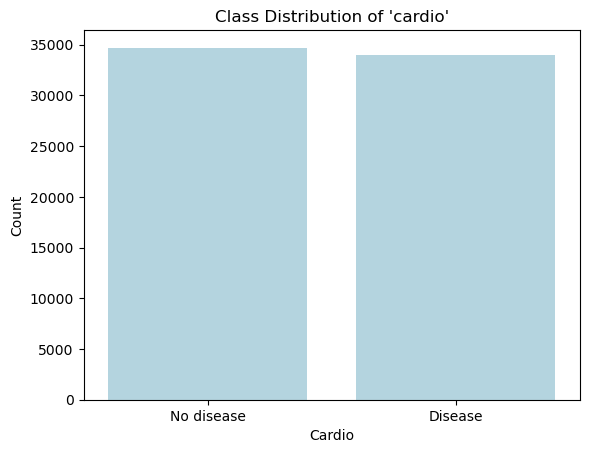

In [7]:
sns.countplot(x='cardio', data = data, color='lightblue')
plt.title("Class Distribution of 'cardio'")
plt.xlabel('Cardio')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels = ['No disease', 'Disease'])
plt.show

**Highlights** 
The dataset shows a nearly equal distribution of patients with and without cardiovascular disease, indicating a well-balanced target variable suitable for classification tasks.

#### 4.2 Relationship Between Features and Target

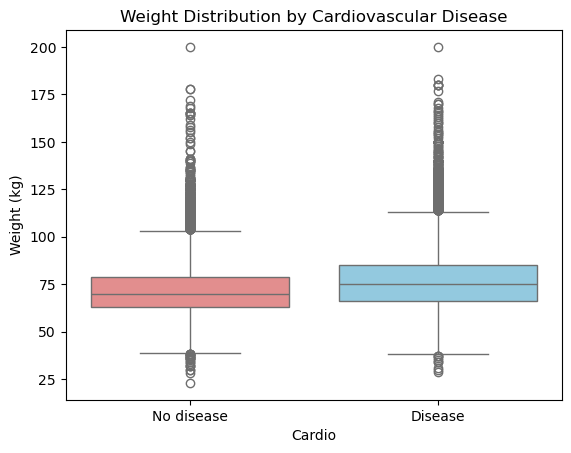

In [8]:
# Weight & Cardio
sns.boxplot(
    x='cardio',
    y='weight',
    hue='cardio',
    data=data,
    palette={0: 'lightcoral', 1: 'skyblue'},
    legend=False
)
plt.xticks([0, 1], ['No disease', 'Disease'])
plt.xlabel('Cardio')
plt.ylabel('Weight (kg)')
plt.title('Weight Distribution by Cardiovascular Disease')
plt.show()

**Highlights**
Patients with cardiovascular disease generally show slightly higher body weight compared to healthy individuals. However, the strong overlap between the distributions suggests that weight alone is insufficient for reliable cardiovascular disease prediction.

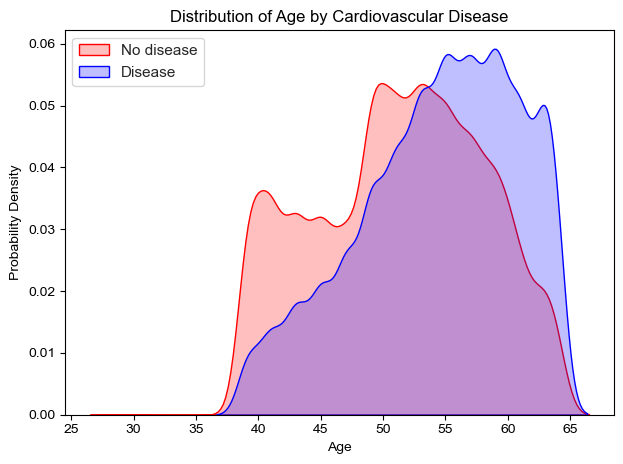

In [9]:
# Age & Cardio
sns.kdeplot(data.loc[(data['cardio']==0), 'age'], color='r', fill=True, label='No disease')
sns.kdeplot(data.loc[(data['cardio']==1), 'age'], color='b', fill=True, label='Disease')
sns.set(style="whitegrid")
plt.xlabel('Age')
plt.ylabel('Probability Density')
plt.title('Distribution of Age by Cardiovascular Disease')
plt.legend()
plt.tight_layout()
plt.savefig('eda_visualizations.png', dpi=300, bbox_inches='tight')
plt.show()

**Highlights**  
Age is positively associated with cardiovascular disease — people with the disease tend to be older on average.  
The blue curve (Disease) is shifted to the right compared to the red curve (No disease).  
This indicates that higher ages are more common among patients with cardiovascular disease.  
There is significant overlap between the two curves.  
The “No disease” group peaks around ~45–50 years.  
The “Disease” group peaks around ~55–60 years.  
This suggests increasing risk with age.  
Lower probability at young ages for disease.  
At ages ~35–45, the probability density for disease is noticeably lower.  
Younger individuals are less likely to have cardiovascular disease in this dataset, but only Age alone cannot perfectly separate healthy vs diseased individuals.

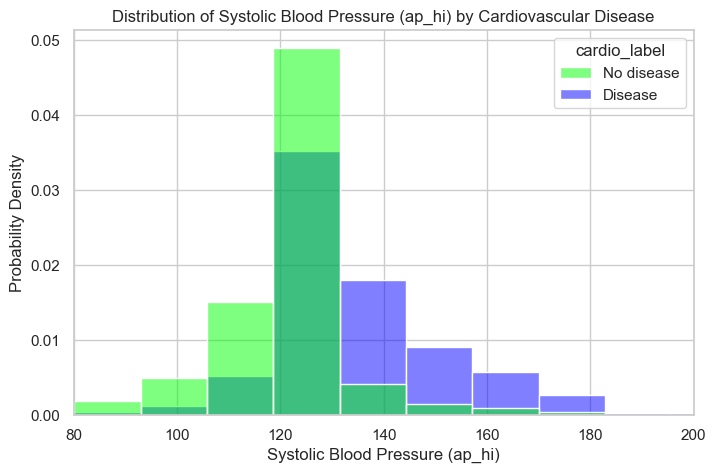

In [10]:
# Systolic blood pressure (ap_hi) & Cardio
data['cardio_label'] = data['cardio'].map({
    0: 'No disease',
    1: 'Disease'
})
plt.figure(figsize=(8, 5))
sns.histplot(
    data=data,
    x='ap_hi',
    hue='cardio_label',
    bins=30,
    stat='density',
    common_norm=False,
    palette={'No disease': 'lime', 'Disease': 'blue'},
    alpha=0.5
)
plt.xlim(80, 200)
plt.xlabel('Systolic Blood Pressure (ap_hi)')
plt.ylabel('Probability Density')
plt.title('Distribution of Systolic Blood Pressure (ap_hi) by Cardiovascular Disease')
#plt.legend(title='Cardio', labels=['No disease', 'Disease'])
plt.show()

**Highlights**  
Although both groups have the highest density around ~120 mmHg, patients with cardiovascular disease show a noticeably higher density in the elevated systolic blood pressure range (130–140 mmHg). This suggests that normal blood pressure is common in both groups, but higher systolic values are more strongly associated with disease risk.

#### 4.3 Correlation Analysis

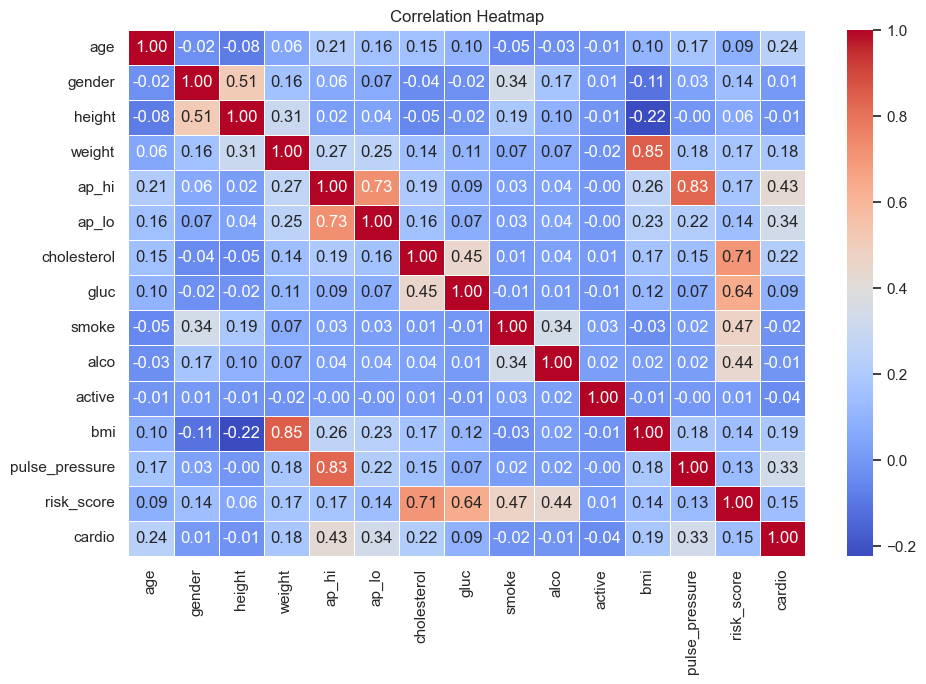

In [11]:
plt.figure(figsize=(10, 7))
corr_matrix = data.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

**Highlights**  
The correlation analysis indicates that blood pressure-related features, particularly systolic blood pressure and pulse pressure, have the strongest association with cardiovascular disease (correlation coefficients are 0.43, 0.34 and 0.33).  
Age, cholesterol level, BMI, and weight also show positive relationships with disease presence (correlation coefficients are 0.24, 0.22, 0.19 and 0.18), while physical activity demonstrates only weak correlations with other variables.

### 5. Data Preprocessing

#### 5.1 Outlier removal (blood pressure only)

In [12]:
from scipy.stats import zscore
bp_columns = ['ap_hi', 'ap_lo']
z_scores = data[bp_columns].apply(zscore)
threshold = 4
outliers = data[(z_scores.abs() > threshold).any(axis=1)]
print(f'Number of detected outliers: {len(outliers)}')

# Remove outliers
data_cleaned = data.drop(outliers.index)

# Reset index
data_cleaned = data_cleaned.reset_index(drop=True)

print(f'Original dataset shape: {data.shape}')
print(f'Cleaned dataset shape: {data_cleaned.shape}')

data = data_cleaned.copy()

Number of detected outliers: 364
Original dataset shape: (68681, 16)
Cleaned dataset shape: (68317, 16)


#### 5.2 Encoding

In [13]:
data = data.drop(columns=['cardio_label'], errors='ignore')
X = data.drop(columns='cardio')
y = data['cardio']

X_encoded = pd.get_dummies(
    X,
    columns=['gender', 'cholesterol', 'gluc'],
    drop_first=False,
    dtype=int
)
data_encoded = pd.concat([X_encoded, data['cardio']], axis=1)

#### 5.3 Train-Test Split

In [14]:
X = data_encoded.drop(columns='cardio')
y = data_encoded['cardio']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

#### 5.4 Feature Selection

In [15]:
fs = SelectKBest(f_classif, k=13)
X_train = fs.fit_transform(X_train, y_train)
X_test = fs.transform(X_test)

#### 5.5 Feature Scaling

In [16]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train.shape

(54653, 13)

So what i could say about shape of my train features:

- 54 653 - amount of rows in my train dataset
- 13 - amount of features (columns) in my train dataset

### 6. Model Development


Training Single-Layer Perceptron (Keras version) ...
Epoch 1/75
1452/1452 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5981 - loss: 0.6699 - val_accuracy: 0.6503 - val_loss: 0.6396
Epoch 2/75
1452/1452 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6607 - loss: 0.6334 - val_accuracy: 0.6768 - val_loss: 0.6195
Epoch 3/75
1452/1452 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6882 - loss: 0.6165 - val_accuracy: 0.7081 - val_loss: 0.6044
Epoch 4/75
1452/1452 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7038 - loss: 0.6040 - val_accuracy: 0.7108 - val_loss: 0.5938
Epoch 5/75
1452/1452 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7111 - loss: 0.5948 - val_accuracy: 0.7165 - val_loss: 0.5856
Epoch 6/75
1452/1452 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7155 - loss: 0.5879 - val_accuracy: 0.7215 - val_loss: 0.5795
Epoch 7/75
1452/1452 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7179 - loss: 0.5826 - val_accuracy: 0.7197 - val_loss: 0.5753
Epoch 8/75
1452/1452 ━━━━━━━━━━━━━━━

<Figure size 400x400 with 0 Axes>

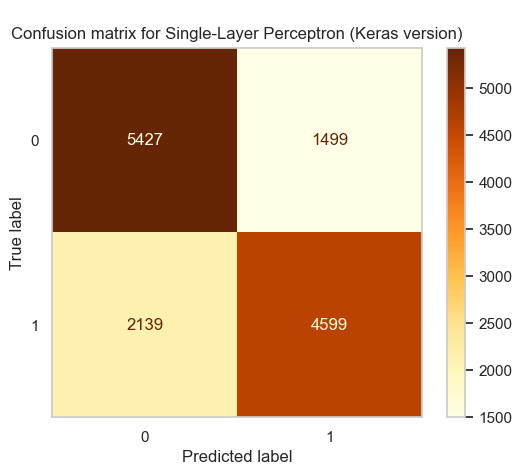


Training Multi-Layer Perceptron (Keras version) ...
Epoch 1/100
1452/1452 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6976 - loss: 0.5892 - val_accuracy: 0.7277 - val_loss: 0.5498
Epoch 2/100
1452/1452 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7189 - loss: 0.5647 - val_accuracy: 0.7304 - val_loss: 0.5455
Epoch 3/100
1452/1452 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7237 - loss: 0.5611 - val_accuracy: 0.7318 - val_loss: 0.5444
Epoch 4/100
1452/1452 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7225 - loss: 0.5600 - val_accuracy: 0.7304 - val_loss: 0.5436
Epoch 5/100
1452/1452 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7238 - loss: 0.5589 - val_accuracy: 0.7310 - val_loss: 0.5423
Epoch 6/100
1452/1452 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7235 - loss: 0.5573 - val_accuracy: 0.7285 - val_loss: 0.5451
Epoch 7/100
1452/1452 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7260 - loss: 0.5564 - val_accuracy: 0.7318 - val_loss: 0.5411
Epoch 8/100
1452/1452 ━━━━━━━━

<Figure size 400x400 with 0 Axes>

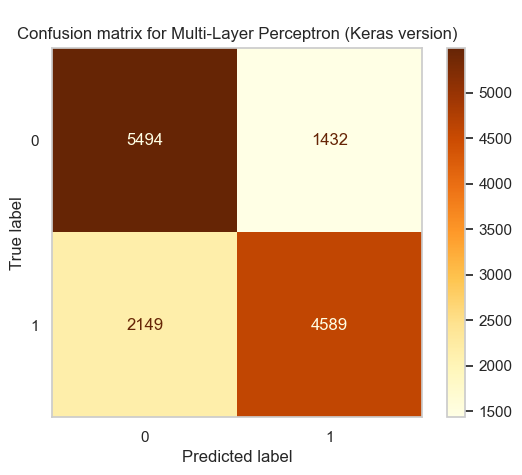


Training Residual MLP (Keras version) ...
Epoch 1/100
1452/1452 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7100 - loss: 0.5743 - val_accuracy: 0.7309 - val_loss: 0.5480
Epoch 2/100
1452/1452 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7258 - loss: 0.5588 - val_accuracy: 0.7327 - val_loss: 0.5468
Epoch 3/100
1452/1452 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7262 - loss: 0.5575 - val_accuracy: 0.7315 - val_loss: 0.5419
Epoch 4/100
1452/1452 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7268 - loss: 0.5554 - val_accuracy: 0.7251 - val_loss: 0.5507
Epoch 5/100
1452/1452 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7264 - loss: 0.5545 - val_accuracy: 0.7349 - val_loss: 0.5402
Epoch 6/100
1452/1452 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7269 - loss: 0.5532 - val_accuracy: 0.7343 - val_loss: 0.5416
Epoch 7/100
1452/1452 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7278 - loss: 0.5527 - val_accuracy: 0.7373 - val_loss: 0.5394
Epoch 8/100
1452/1452 ━━━━━━━━━━━━━━━━━━

<Figure size 400x400 with 0 Axes>

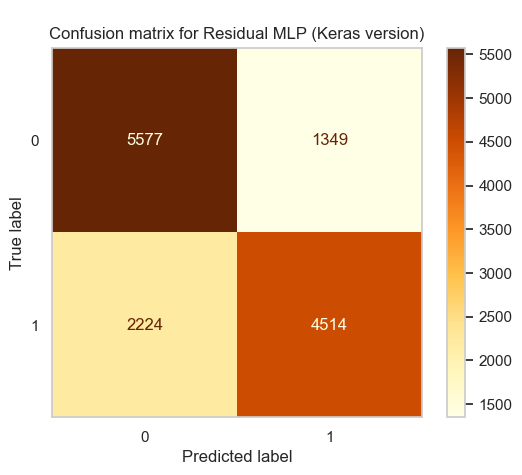

In [17]:
inp = X_train.shape[1]

def build_model():
    model = Sequential([
        Input(shape=(inp,)),        
        Dense(1, activation='sigmoid')
    ])
    return model

def build_mlp():
    model = Sequential([
        Input(shape=(inp,)),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    return model

def build_residual_mlp():
    inputs = Input(shape=(inp,))
    
    # First block
    x = Dense(64, activation='relu')(inputs)
    x = Dense(64, activation='relu')(x)
    
    # Skip connection from input
    skip = Dense(64)(inputs)
    x = Add()([x, skip])
    
    # Second block
    x = Dense(32, activation='relu')(x)
    x = Dropout(0.3)(x)
    
    outputs = Dense(1, activation='sigmoid')(x)
    model = Model(inputs, outputs)
    return model

def train_model(builder, name, epochs=50, batch_size=32):
    print(f'\nTraining {name} ...')
    
    model = builder()
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    start = time.time()
    history = model.fit(X_train, y_train, validation_split=0.15, epochs=epochs, batch_size=batch_size, callbacks=[es], verbose=1)
    runtime = time.time() - start
    
    y_pred_prob = model.predict(X_test).ravel()
    y_pred = (y_pred_prob >= 0.5).astype(int)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    cr = classification_report(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_pred_prob)

    print(f'\n--- {name} ---\n')
    print(f'Accuracy: {acc:.4f}')
    print(f'AUC: {auc_score:.4f}')
    print(f"Runtime: {runtime:.2f} sec")
    print('\nConfusion Matrix:')
    print(cm)
    print('\nClassification report:')
    print(cr)

    # TODO: plot the confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    plt.figure(figsize=(4, 4))
    disp.plot(cmap='YlOrBr')
    plt.title(f'\nConfusion matrix for {name}')
    plt.grid(False)
    plt.show()

    # Plot ROC Curve
    #fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    #plt.figure(figsize=(7,7))
    #plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.4f})', lw=2, color='brown')
    #plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.50)')
    #plt.xlabel('False Positive Rate')
    #plt.ylabel('True Positive Rate')
    #plt.title(f'\nROC Curve for {name}')
    #plt.legend(loc='lower right')
    #plt.grid(True)
    #plt.show()
    
    return {
        'model_name': name,
        'accuracy': acc,
        'auc': auc_score,        
        'epochs_trained': len(history.history['loss']),
        'runtime_sec': runtime,
        'history': history
    }

results = []
results.append(train_model(build_model, 'Single-Layer Perceptron (Keras version)', epochs=75, batch_size=32))
results.append(train_model(build_mlp, 'Multi-Layer Perceptron (Keras version)', epochs=100, batch_size=32))
results.append(train_model(build_residual_mlp, 'Residual MLP (Keras version)', epochs=100, batch_size=32))

### 7. Model Evaluation and Comparison

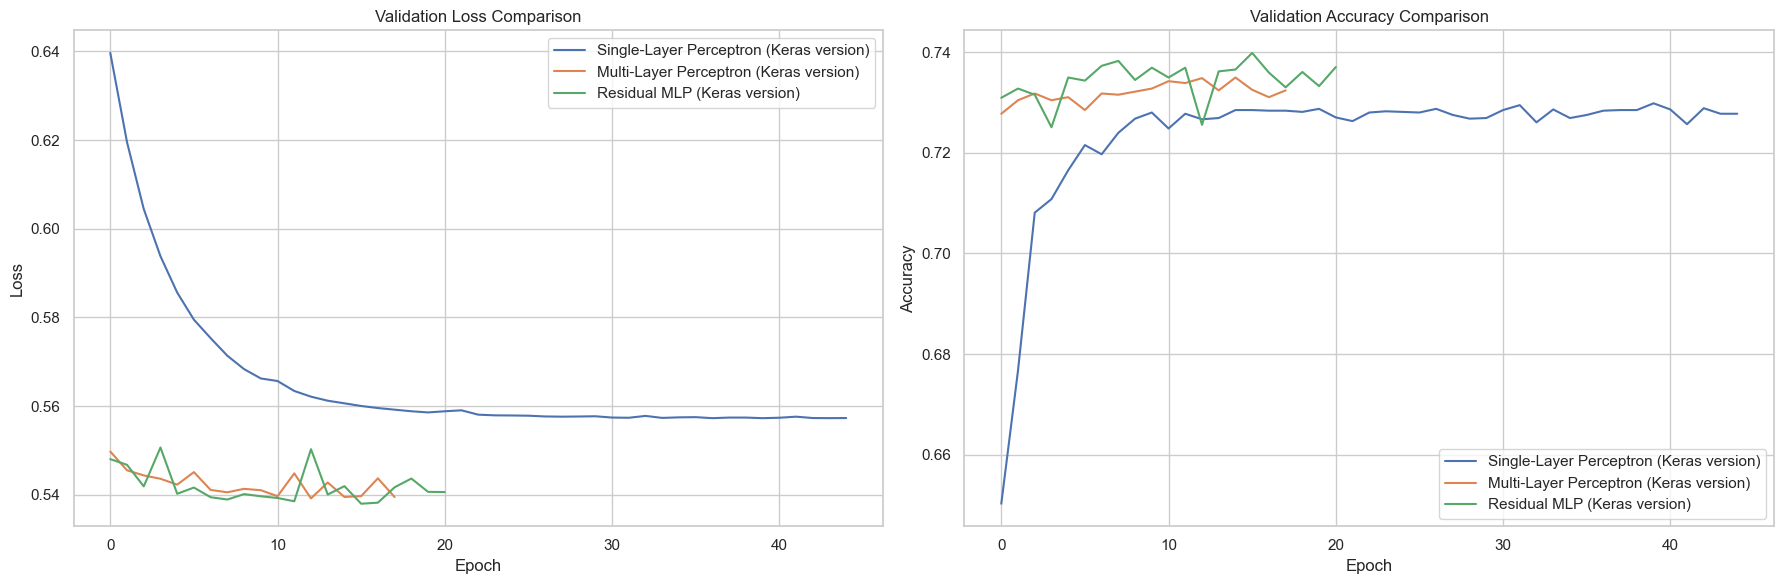

,model_name,accuracy,auc,epochs_trained,runtime_sec
0,Single-Layer Perceptron (Keras version),0.7338,0.7947,45,165.58
1,Multi-Layer Perceptron (Keras version),0.7379,0.8019,18,81.08
2,Residual MLP (Keras version),0.7385,0.8021,21,103.19


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# LEFT: Validation Loss
for result in results:
    history = result['history']
    model_name = result['model_name']

    axes[0].plot(
        history.history['val_loss'],
        label=model_name
    )

axes[0].set_title('Validation Loss Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True)
axes[0].legend()


# RIGHT: Validation Accuracy
for result in results:
    history = result['history']
    model_name = result['model_name']

    axes[1].plot(
        history.history['val_accuracy'],
        label=model_name
    )

axes[1].set_title('Validation Accuracy Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True)
axes[1].legend()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

df_results = pd.DataFrame(results)[[
    'model_name',
    'accuracy',
    'auc',
    'epochs_trained',
    'runtime_sec'
]]

df_results['accuracy'] = df_results['accuracy'].round(4)
df_results['auc'] = df_results['auc'].round(4)
df_results['runtime_sec'] = df_results['runtime_sec'].round(2)

df_results

- Deeper architectures achieved better validation performance.
- Residual connections improved convergence speed.
- Validation loss stabilized quickly, indicating stable training behavior.
- All models achieved relatively similar accuracy, but deeper models showed better AUC scores.
  
*The experimental results demonstrate that deeper neural network architectures outperform a simple single-layer perceptron on the cardiovascular disease prediction task.*

### 8. Final Model Selection
Best Performing Model
- **Model: Residual MLP**
- Accuracy: 73.85%
- AUC: 0.8021
- Training Epochs: 21

The Residual MLP achieved the highest AUC score and the best balance between predictive performance and computational efficiency, making it the final selected model for this project.